# P2Pネットワークとトランザクションのライフサイクル

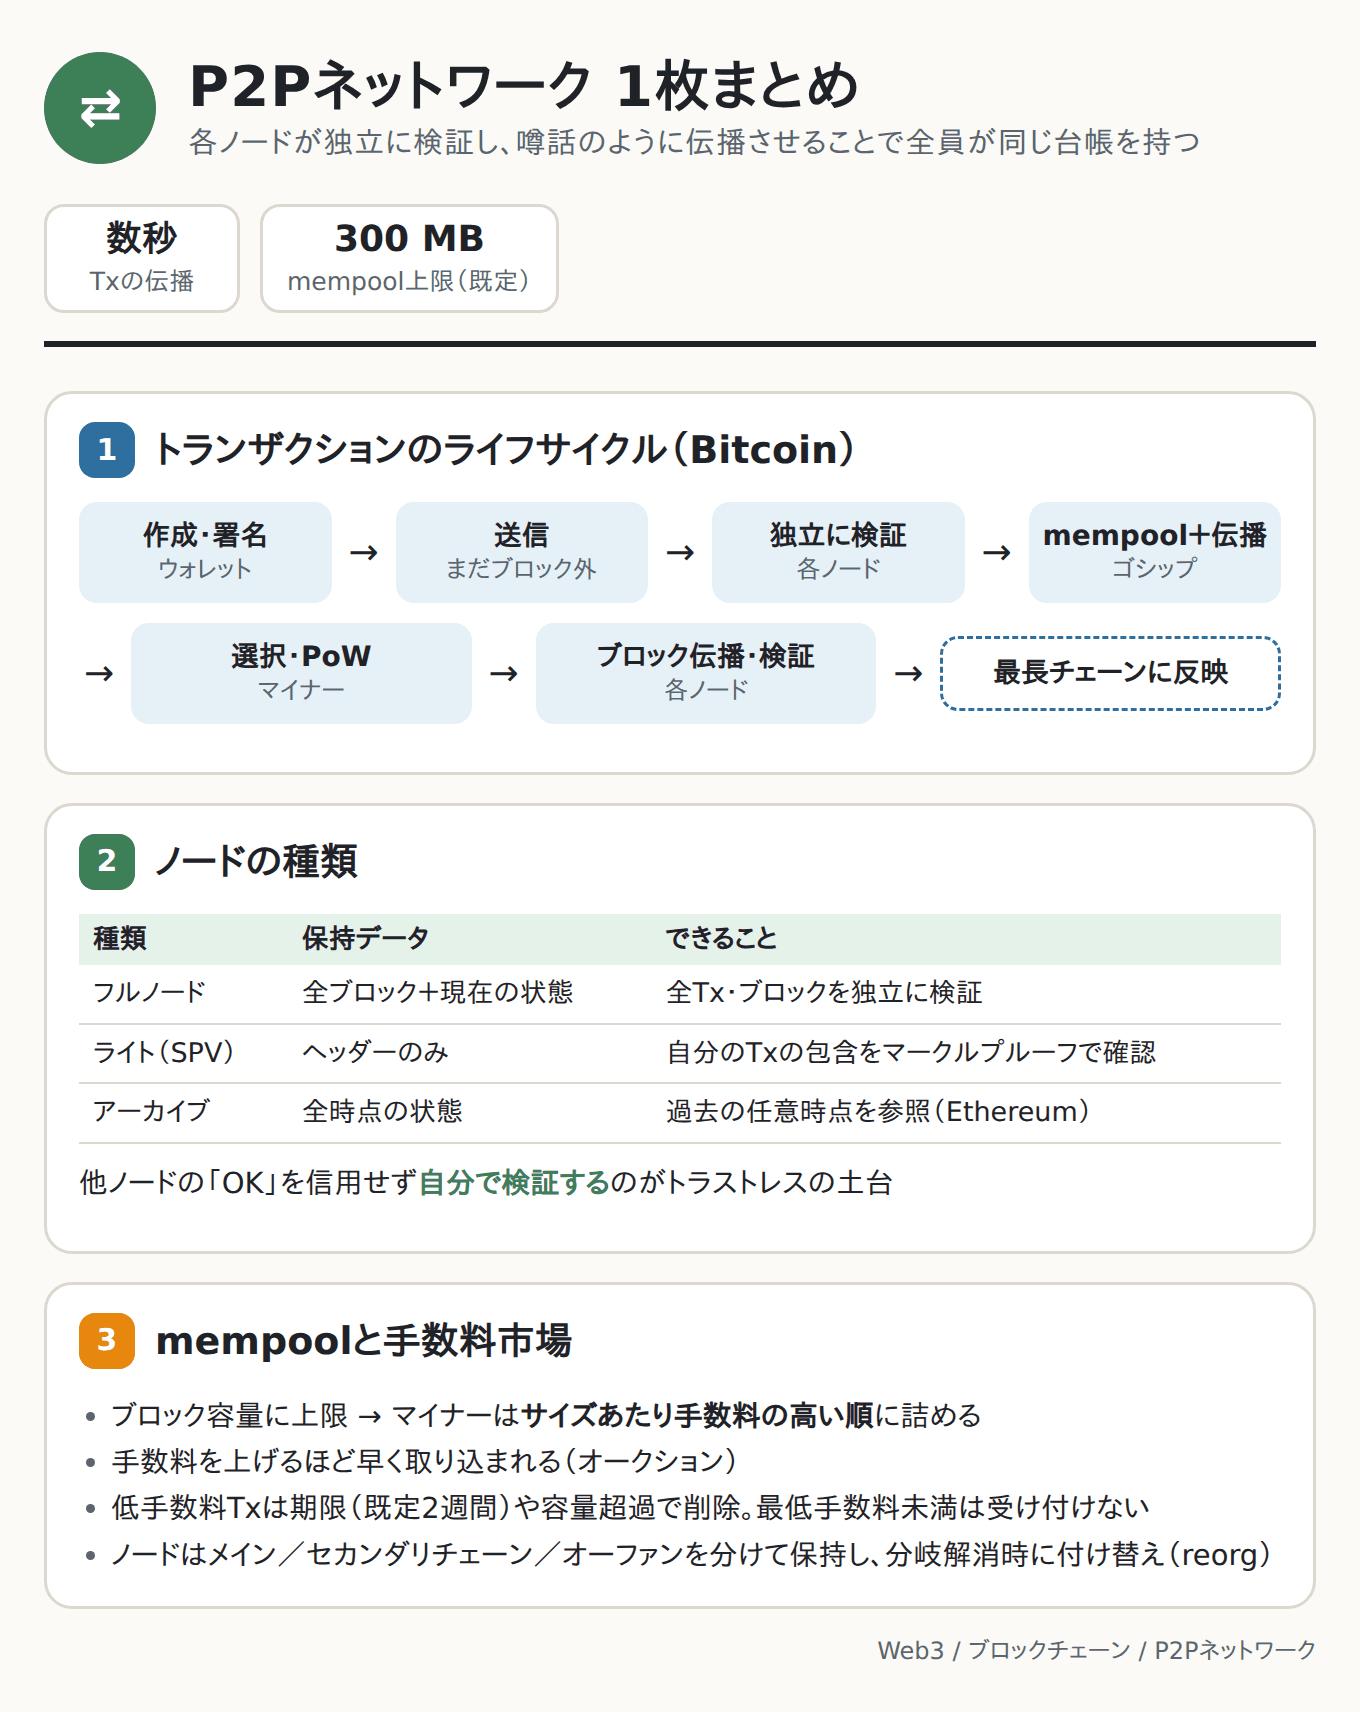

## P2Pネットワーク

ブロックチェーンのノードは、中央サーバーを介さず互いに直接接続する **P2P（Peer-to-Peer）ネットワーク** を構成する。各ノードは数個〜数十個の隣接ノード（ピア）と接続し、受け取った情報をさらに隣接ノードへ転送する。

噂話が広がるように情報が拡散するので、**ゴシッププロトコル（gossip protocol）** と呼ばれる。Bitcoinでは、トランザクションは数秒以内にネットワークの大半のノードに行き渡る。

## ノードの種類

| 種類 | 保持するデータ | できること | Bitcoinでの目安 |
| --- | --- | --- | --- |
| フルノード | 全ブロック、現在の状態（UTXOセット等） | すべてのトランザクション・ブロックを独立に検証 | 数百GB |
| ライトノード（SPVノード） | ブロックヘッダーのみ | 自分に関係する取引がブロックに含まれるかをマークルプルーフで確認 | 数十〜100MB |
| マイナー／バリデータ | フルノードのデータ | ブロックの生成 | — |
| アーカイブノード（Ethereum） | 全ブロックと、全時点の状態 | 過去の任意の時点の状態を参照 | 数十TB |

**SPV（Simplified Payment Verification）** はNakamotoの論文で提案された方式。ライトノードは取引の正当性そのものは検証できず、「その取引を含むブロックの上に十分な作業量が積まれている」ことだけを確認する。スマホの軽量ウォレットなどで使われる。

## 独立した検証

ブロックチェーンのトラストレス性を支えるのが、**各フルノードが受け取ったデータを独立に検証する**という原則。他のノードが「OKだった」と言っていても、自分で同じルール（プロトコル仕様）に照らしてチェックする。

不正なトランザクションやブロックは検証に失敗して転送されないので、ネットワークに広がらない。ルールをすべてのノードが共有しているため、結果としてどのノードも同じブロックチェーンを持つことになる。

## トランザクションのライフサイクル（Bitcoin）

```mermaid
sequenceDiagram
    participant W as ウォレット
    participant N as ノード
    participant M as マイナー
    participant O as 他のノード
    W->>W: トランザクションを作成し署名
    W->>N: トランザクションを送信
    N->>N: 独立に検証
    N->>N: mempoolに保持
    N->>O: 隣接ノードへ伝播（ゴシップ）
    M->>M: mempoolからトランザクションを選択
    M->>M: ブロックに格納しPoWを実行
    M->>O: 完成したブロックを伝播
    O->>O: ブロックを独立に検証
    O->>O: 最長チェーンに反映
```

1. **作成**：ウォレットがトランザクションを作り、秘密鍵で署名する
2. **送信**：接続しているノードに送る。この時点ではまだブロックに入っていない
3. **検証**：受け取ったノードが構文、署名、参照先のUTXOが未使用か、手数料が最低額以上か、などを検証する
4. **mempool**：有効なトランザクションは各ノードのメモリ上の待機領域（mempool）に保持され、隣接ノードへ伝播される
5. **選択**：マイナーがmempoolからブロックに入れるトランザクションを選ぶ
6. **ブロック生成**：トランザクションを格納し、PoWを行ってブロックを完成させる
7. **ブロック伝播・検証**：ブロックがネットワークに伝播し、各ノードが中のトランザクションも含めて検証する
8. **反映**：有効なら自分のチェーンに追加し、最長チェーンを正統なものとして扱う

## mempoolと手数料市場

ブロックの容量には上限があるため、マイナーは **手数料率（単位サイズあたりの手数料）が高いトランザクションから優先的に** ブロックに入れる。ユーザーにとっては、手数料を高くするほど早くブロックに取り込まれる。こうしてブロック容量をめぐるオークションのような **手数料市場（fee market）** ができる。

- Bitcoinでは手数料はトランザクションのデータサイズ（入出力の数）で決まり、送金額には依存しない
- 手数料が低いトランザクションはmempoolに長く残り、一定期間（デフォルト2週間）経つか、mempoolの容量（デフォルト300MB）を超えると手数料の低いものから削除される
- 最低手数料（minRelayTxFee）に満たないトランザクションは検証の段階で弾かれ、スパム対策になっている

## ノードが保持するデータ

| データ | 内容 |
| --- | --- |
| ブロックチェーン | 全ブロックのデータ |
| ブロックインデックス | ブロックハッシュをキーにしたブロックのメタ情報。参照関係の検証に使う |
| UTXOセット（Bitcoin） | 現時点のすべての未使用出力。`(txid, 出力番号)` をキー、金額とロック条件をバリューとするデータベース。トランザクション検証時に参照する |
| ステート（Ethereum） | 全アカウントの残高・コントラクトの状態 |
| mempool | 未承認トランザクション |

ブロックは受け取った順に処理できるとは限らないため、Bitcoinのノードは

- **メインチェーン**：現時点で最長のチェーン
- **セカンダリチェーン**：メインチェーンから分岐したブロック
- **オーファンブロックプール**：親ブロックがまだ届いていないブロック

を分けて保持し、分岐が解消されたらメインチェーンを付け替える（**reorg, reorganization**）。